<a href="https://colab.research.google.com/github/priyanshi-nigam123/Ore_Quality_prediction/blob/main/Ore_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#connecting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
#loading dataset
file_path = '/content/drive/MyDrive/Dataset for mining/MiningProcess_Flotation_Plant_Database.csv'

In [10]:
mining_df = pd.read_csv(file_path)

In [11]:
mining_df

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,10-03-2017 01:00,55.20,16.98,3019.53,557.434,395.713,10.06640,1.74000,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,10-03-2017 01:00,55.20,16.98,3024.41,563.965,397.383,10.06720,1.74000,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,10-03-2017 01:00,55.20,16.98,3043.46,568.054,399.668,10.06800,1.74000,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,10-03-2017 01:00,55.20,16.98,3047.36,568.665,397.939,10.06890,1.74000,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,10-03-2017 01:00,55.20,16.98,3033.69,558.167,400.254,10.06970,1.74000,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737448,09-09-2017 23:00,49.75,23.20,2710.94,441.052,386.570,9.62129,1.65365,302.344,298.786,...,313.695,392.160,430.702,872.008,418.725,497.548,446.357,416.892,64.27,1.71
737449,09-09-2017 23:00,49.75,23.20,2692.01,473.436,384.939,9.62063,1.65352,303.013,301.879,...,236.700,401.505,404.616,864.409,418.377,506.398,372.995,426.337,64.27,1.71
737450,09-09-2017 23:00,49.75,23.20,2692.20,500.488,383.496,9.61874,1.65338,303.662,307.397,...,225.879,408.899,399.316,867.598,419.531,503.414,336.035,433.130,64.27,1.71
737451,09-09-2017 23:00,49.75,23.20,1164.12,491.548,384.976,9.61686,1.65324,302.550,301.959,...,308.115,405.107,466.832,876.591,407.299,502.301,340.844,433.966,64.27,1.71


In [7]:
mining_df['date'] = pd.to_datetime(mining_df['date'], dayfirst=True)

In [12]:
mining_df.dtypes

,0
date,object
% Iron Feed,float64
% Silica Feed,float64
Starch Flow,float64
Amina Flow,float64
Ore Pulp Flow,float64
Ore Pulp pH,float64
Ore Pulp Density,float64
Flotation Column 01 Air Flow,float64
Flotation Column 02 Air Flow,float64


In [13]:
mining_df.isnull().sum()

,0
date,0
% Iron Feed,0
% Silica Feed,0
Starch Flow,0
Amina Flow,0
Ore Pulp Flow,0
Ore Pulp pH,0
Ore Pulp Density,0
Flotation Column 01 Air Flow,0
Flotation Column 02 Air Flow,0


In [14]:
#Gives statistical summary of the Dataset
mining_df.describe()
print("The average percentage is : ", mining_df['% Silica Concentrate'].mean())
print("The maximum percentage is : ", mining_df['% Iron Concentrate'].max())

The average percentage is :  2.3267632513567698
The maximum percentage is :  68.01


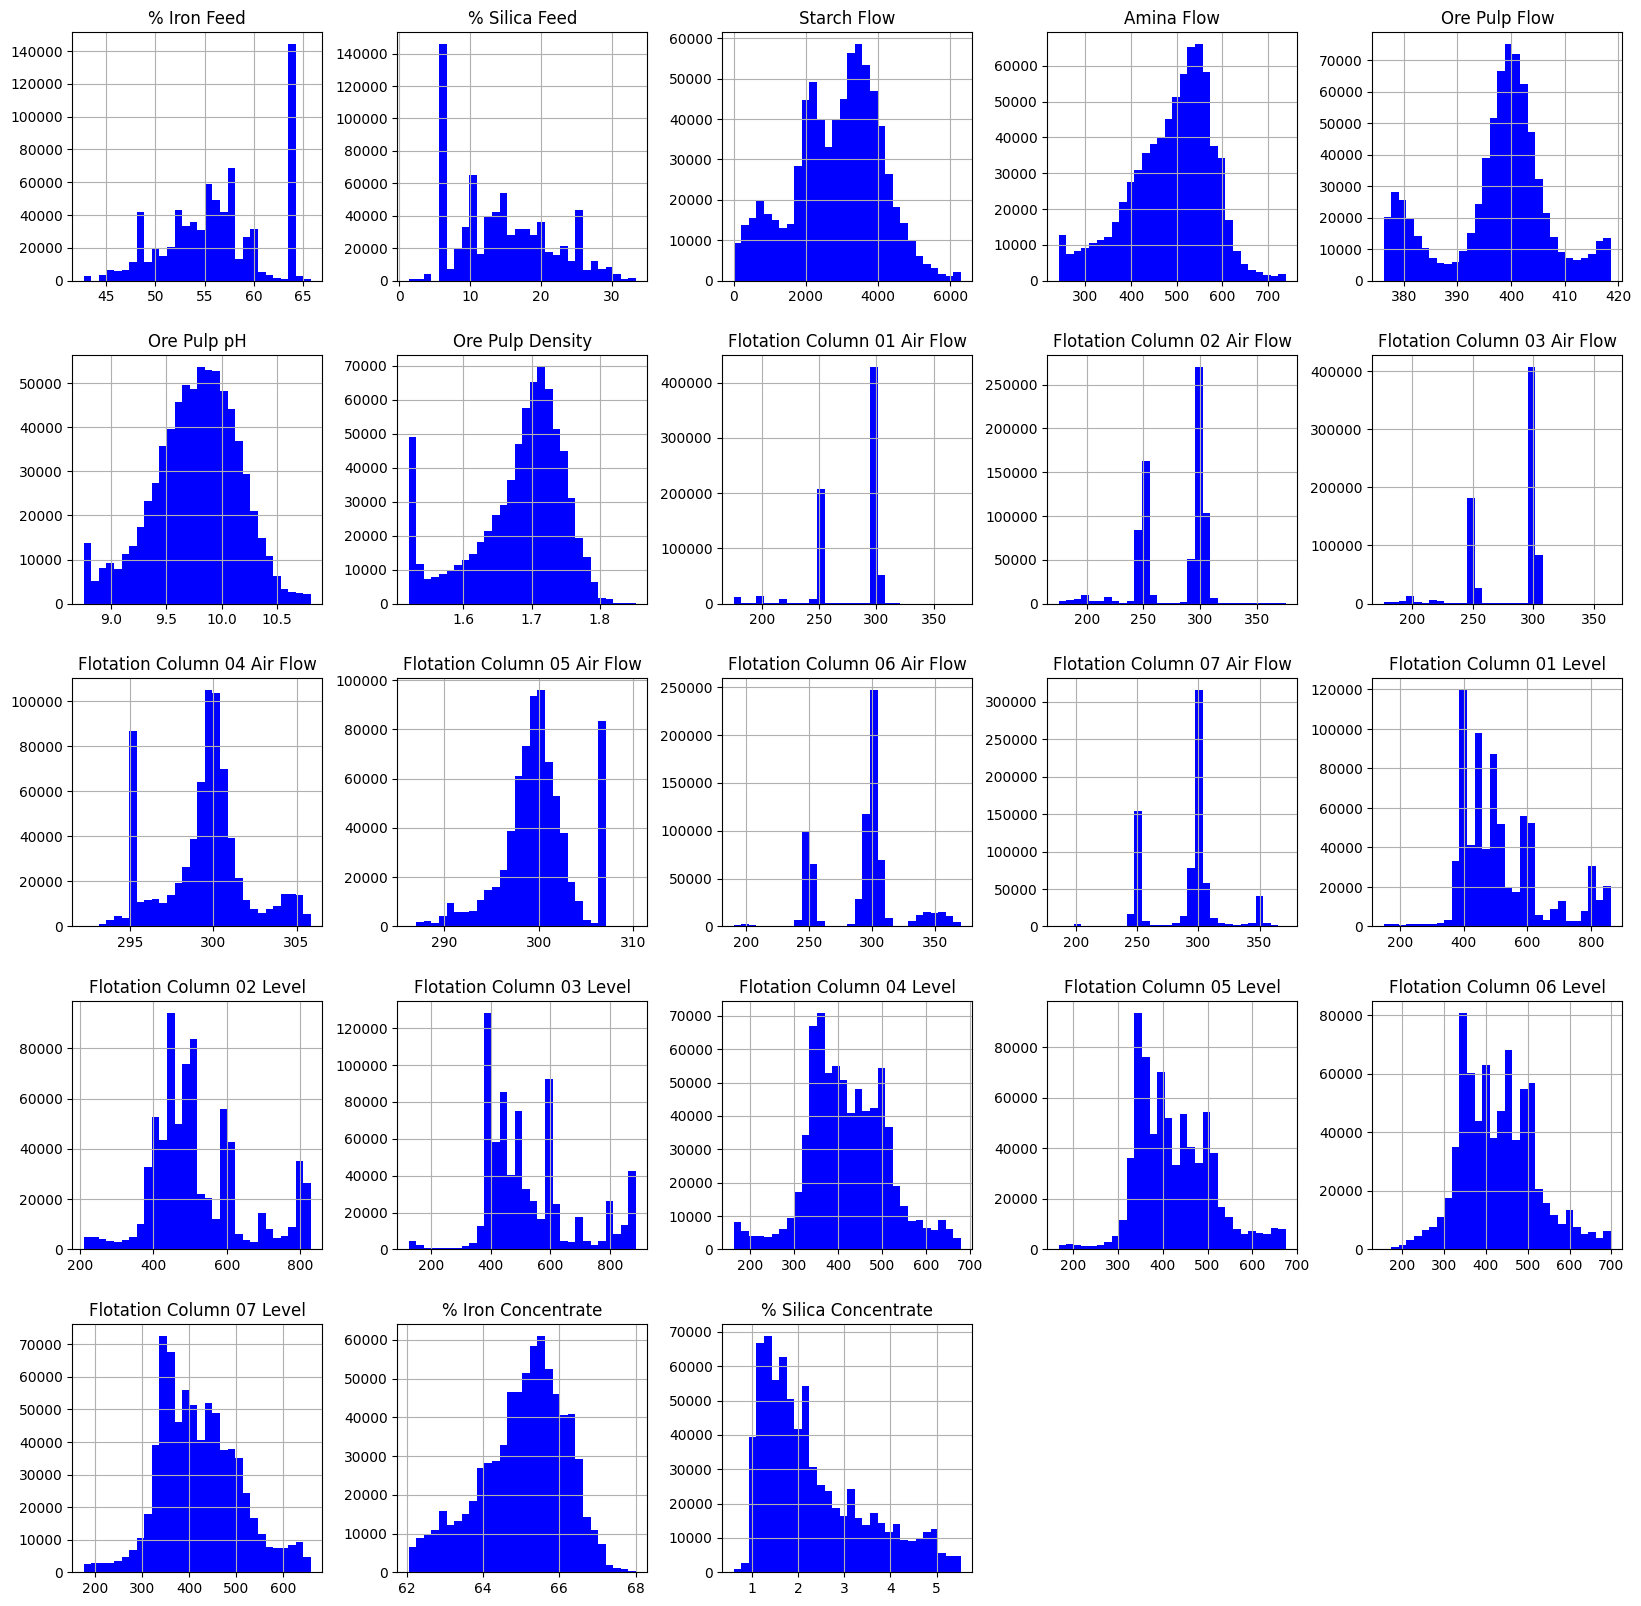

In [15]:
mining_df.hist(bins = 30,figsize = (20,20), color = 'b')
plt.show()

In [16]:
mining_df.corr(numeric_only=True)

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
% Iron Feed,1.000000,-0.971833,0.027981,-0.088148,0.160705,0.007451,-0.125518,-0.062379,-0.169430,-0.062207,...,-0.016356,0.029499,0.020839,0.015191,0.016108,0.023288,0.003694,0.025723,0.055424,-0.077052
% Silica Feed,-0.971833,1.000000,-0.016073,0.078735,-0.150788,0.008014,0.104497,0.091757,0.182573,0.084197,...,0.045300,-0.038291,-0.036968,-0.022675,-0.034050,-0.043753,-0.019502,-0.046413,-0.044168,0.072724
Starch Flow,0.027981,-0.016073,1.000000,0.254748,0.042703,0.263020,0.226004,0.191131,0.186585,0.183288,...,0.194786,-0.294380,-0.278422,-0.301757,-0.012612,-0.055528,-0.071722,-0.038193,0.069657,-0.066394
Amina Flow,-0.088148,0.078735,0.254748,1.000000,0.212252,0.123690,0.655788,0.111321,0.122911,0.101957,...,0.079558,-0.268536,-0.234454,-0.286968,-0.180301,-0.211712,-0.197758,-0.168050,-0.110148,0.156701
Ore Pulp Flow,0.160705,-0.150788,0.042703,0.212252,1.000000,0.118376,0.012279,-0.137866,-0.118549,-0.140761,...,-0.140914,-0.008579,-0.008049,-0.054351,-0.009784,0.002260,-0.016661,0.016585,0.083120,0.008222
Ore Pulp pH,0.007451,0.008014,0.263020,0.123690,0.118376,1.000000,0.115189,0.163073,0.144935,0.193372,...,0.174684,-0.165739,-0.153557,-0.140070,0.046371,0.013041,-0.075034,0.019021,0.192992,-0.147739
Ore Pulp Density,-0.125518,0.104497,0.226004,0.655788,0.012279,0.115189,1.000000,-0.005142,0.025794,-0.031673,...,-0.052294,-0.111608,-0.093024,-0.149584,-0.087761,-0.140881,-0.099817,-0.086067,0.015580,0.046984
Flotation Column 01 Air Flow,-0.062379,0.091757,0.191131,0.111321,-0.137866,0.163073,-0.005142,1.000000,0.848277,0.954528,...,0.646768,-0.441573,-0.425758,-0.371791,-0.061940,-0.091386,-0.118992,-0.110726,0.098599,-0.219158
Flotation Column 02 Air Flow,-0.169430,0.182573,0.186585,0.122911,-0.118549,0.144935,0.025794,0.848277,1.000000,0.860438,...,0.578578,-0.432033,-0.422855,-0.365535,-0.074312,-0.110512,-0.117619,-0.112403,0.058744,-0.167398
Flotation Column 03 Air Flow,-0.062207,0.084197,0.183288,0.101957,-0.140761,0.193372,-0.031673,0.954528,0.860438,1.000000,...,0.649435,-0.440823,-0.420932,-0.364773,-0.046685,-0.063693,-0.100419,-0.085294,0.100136,-0.218891


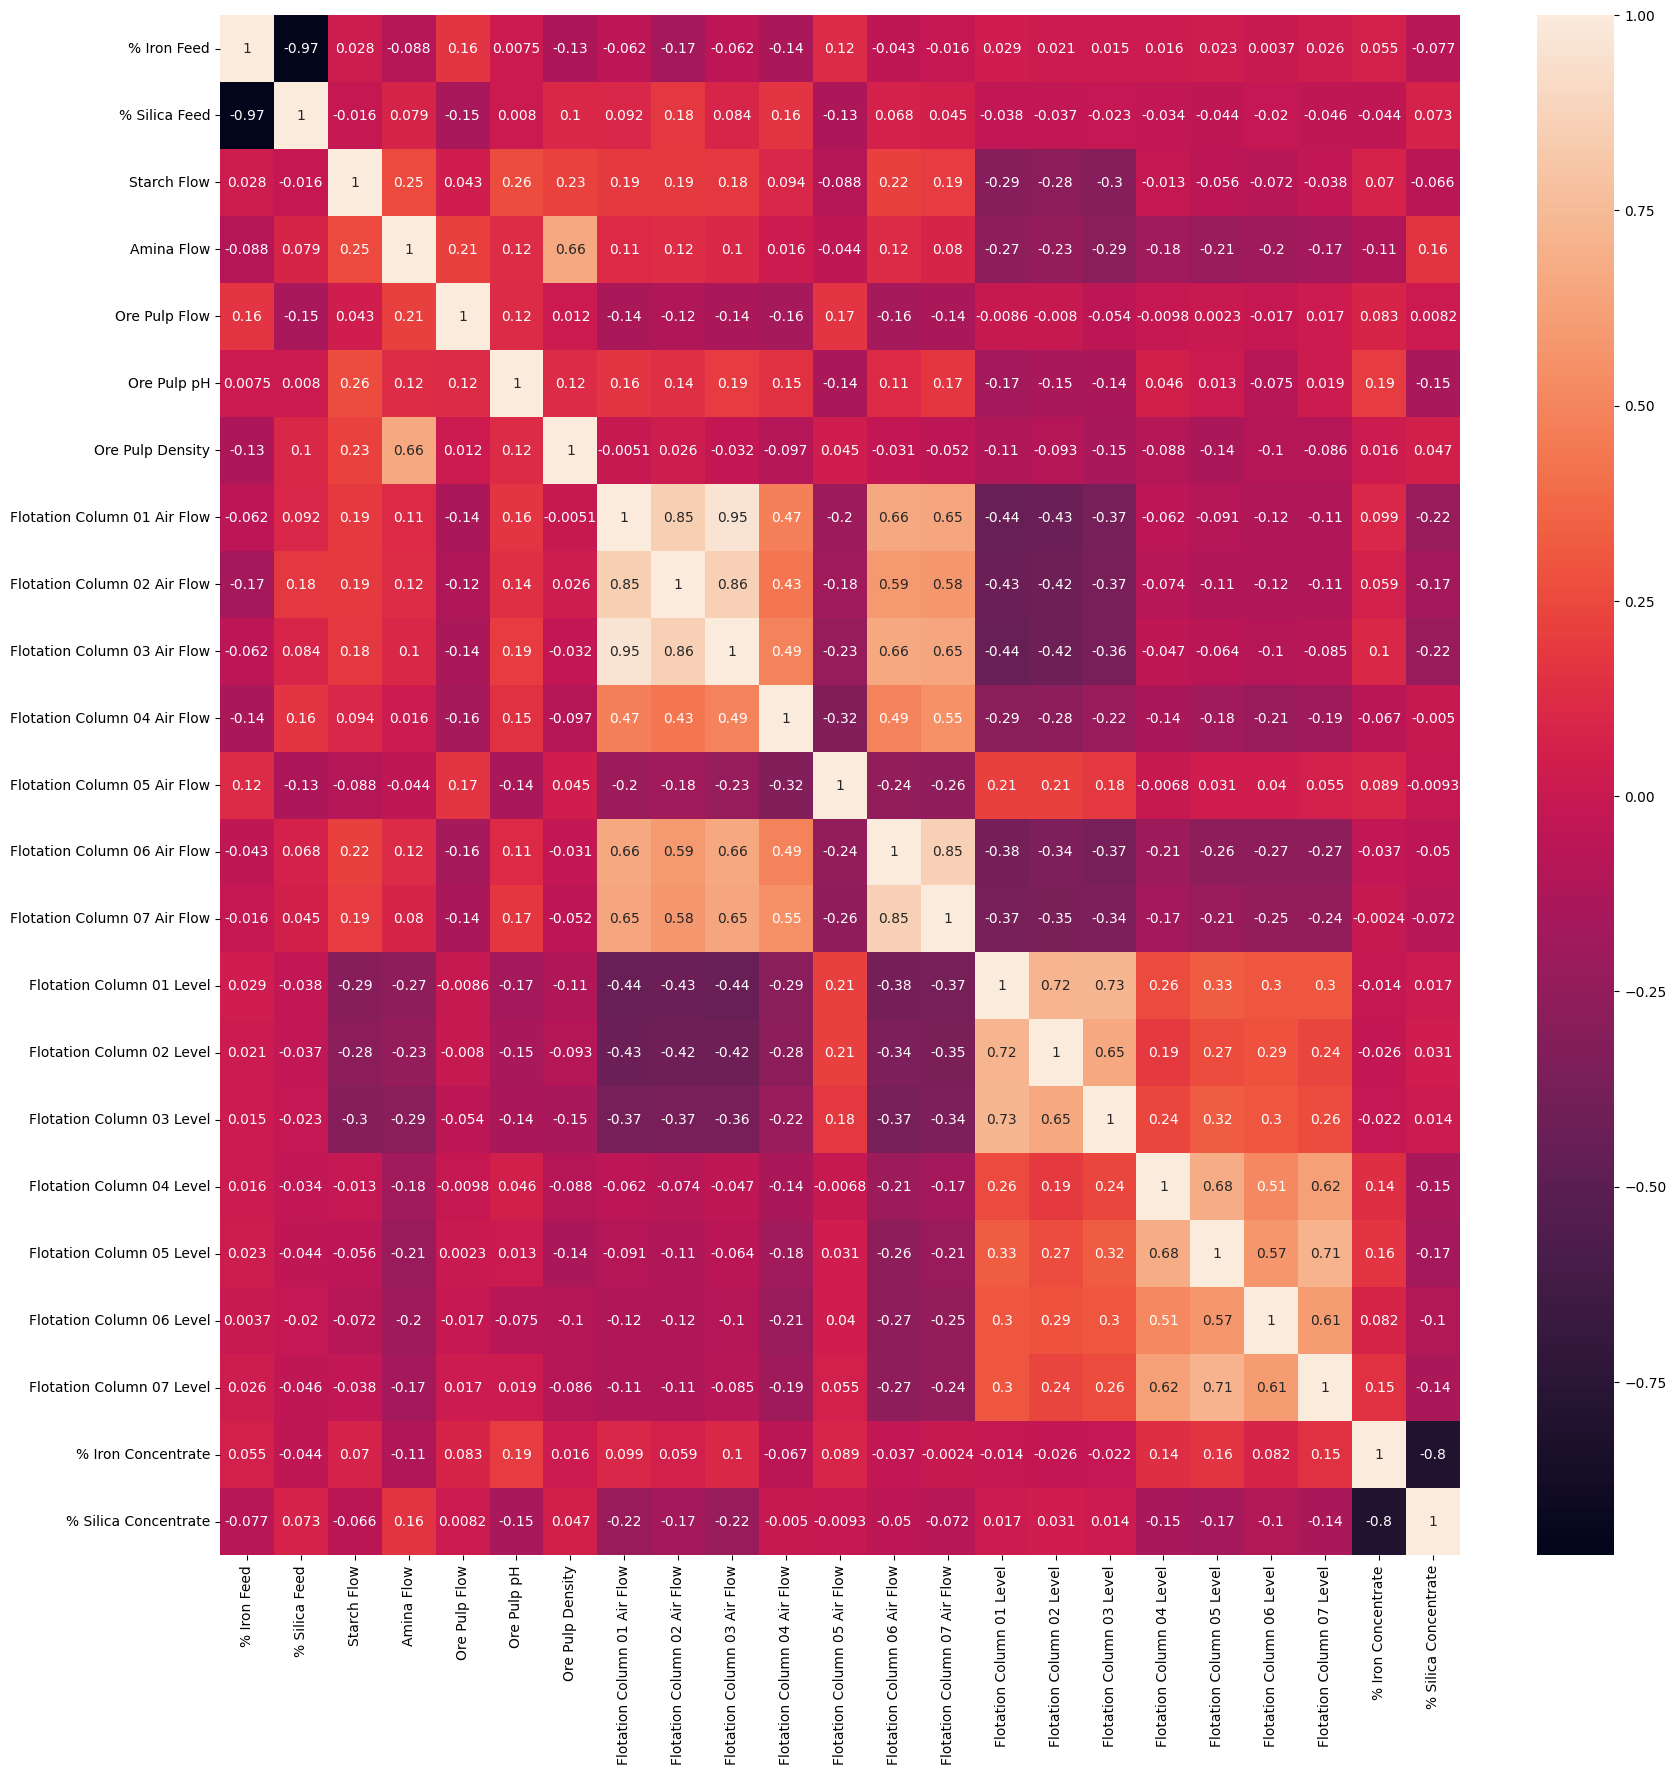

In [17]:
plt.figure(figsize=(20, 20))
sns.heatmap(mining_df.corr(numeric_only=True), annot=True)
plt.show()

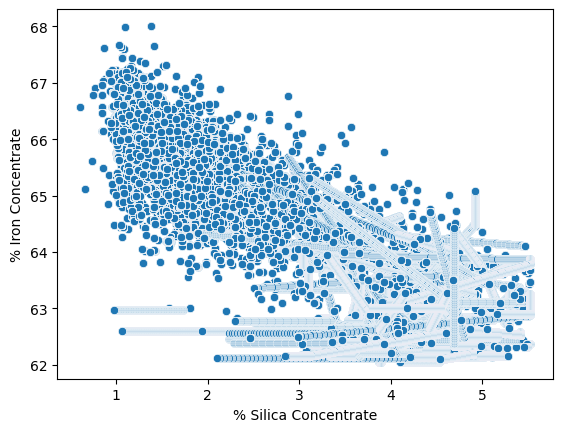

In [18]:
sns.scatterplot(data=mining_df, x='% Silica Concentrate', y='% Iron Concentrate')
plt.show()

<Axes: xlabel='% Iron Feed', ylabel='% Silica Feed'>

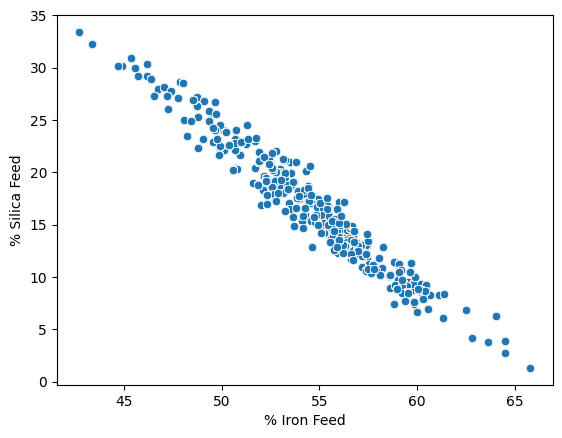

In [19]:
sns.scatterplot(mining_df, x='% Iron Feed', y='% Silica Feed')

In [20]:
#data prepare
df_iron = mining_df.drop(columns = ['% Silica Concentrate', 'date'])
df_iron_target = mining_df['% Silica Concentrate']

In [21]:
df_iron.shape

(737453, 22)

In [22]:
df_iron_target.shape

(737453,)

In [23]:
df_iron = np.array(df_iron)
df_iron_target = np.array(df_iron_target)

In [24]:
# reshaping the array
df_iron_target = df_iron_target.reshape(-1,1)
df_iron_target.shape

(737453, 1)

In [25]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
X = StandardScaler().fit_transform(df_iron)
y_scaler= StandardScaler()
y=y_scaler.fit_transform(df_iron_target)

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

In [27]:
X_train.shape

(516217, 22)

In [28]:
X_test.shape

(221236, 22)

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score

In [37]:
LR_Model = LinearRegression()
LR_Model.fit(X_train,y_train)

LinearRegression()

In [38]:
accuracy_LRModel = LR_Model.score(X_test,y_test)
print("The accuracy of Linear Regression Model is ", accuracy_LRModel)

The accuracy of Linear Regression Model is  0.6798361467999151


In [39]:
from sklearn.tree import DecisionTreeRegressor
DT_Model = DecisionTreeRegressor()
DT_Model.fit(X_train, y_train)
print("DT Accuracy:", DT_Model.score(X_test, y_test))

DT Accuracy: 0.9926495232354108


In [40]:
from sklearn.ensemble import RandomForestRegressor

RF_Model = RandomForestRegressor(n_estimators=50, max_depth=10,
                                  random_state=42, n_jobs=-1)
RF_Model.fit(X_train[:200000], y_train[:200000])
print("RF Accuracy:", RF_Model.score(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RF Accuracy: 0.8923503346534591


In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001, beta_1 = 0.9, beta_2 = 0.999, epsilon = 1e-07, amsgrad = False)
ANN_model = keras.Sequential()
ANN_model.add(Dense(250, input_dim = 22, kernel_initializer='normal',activation='relu'))
ANN_model.add(Dense(500,activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(1000, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(1000, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(500, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(250, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(1, activation = 'linear'))
ANN_model.compile(loss = 'mse', optimizer = 'adam')
ANN_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 250)            │         5,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 500)            │       125,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1000)           │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,251 (8.62 MB)

 Trainable params: 2,259,251 (8.62 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = ANN_model.fit(X_train,y_train,epochs=5,validation_split=0.3)

Epoch 1/5
11293/11293 ━━━━━━━━━━━━━━━━━━━━ 59s 5ms/step - loss: 0.1745 - val_loss: 0.1224
Epoch 2/5
11293/11293 ━━━━━━━━━━━━━━━━━━━━ 49s 4ms/step - loss: 0.1119 - val_loss: 0.1040
Epoch 3/5
11293/11293 ━━━━━━━━━━━━━━━━━━━━ 49s 4ms/step - loss: 0.0939 - val_loss: 0.0751
Epoch 4/5
11293/11293 ━━━━━━━━━━━━━━━━━━━━ 48s 4ms/step - loss: 0.0835 - val_loss: 0.0664
Epoch 5/5
11293/11293 ━━━━━━━━━━━━━━━━━━━━ 49s 4ms/step - loss: 0.0789 - val_loss: 0.0650


In [33]:
result = ANN_model.evaluate(X_test, y_test)
accuracy_ANN = 1 - result
print("Accuracy : {}".format(accuracy_ANN))

6914/6914 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0647
Accuracy : 0.9352748468518257


In [34]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

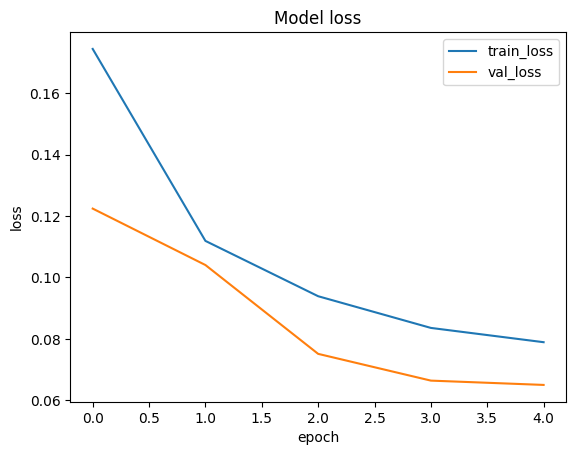

In [42]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss','val_loss'], loc = 'upper right')
plt.show()

In [43]:
import joblib

# ML Models save
joblib.dump(DT_Model, '/content/drive/MyDrive/Dataset for mining/DT_Model.pkl')
joblib.dump(RF_Model, '/content/drive/MyDrive/Dataset for mining/RF_Model.pkl')

# ANN save
ANN_model.save('/content/drive/MyDrive/Dataset for mining/ANN_model.h5')

print("Models saved!")

Models saved!


In [44]:
train_result = ANN_model.evaluate(X_train, y_train)
train_accuracy_ANN = 1 - train_result
print("ANN Training Accuracy:", train_accuracy_ANN)
print("ANN Testing Accuracy:", accuracy_ANN)

16132/16132 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.0626
ANN Training Accuracy: 0.937365710735321
ANN Testing Accuracy: 0.9352748468518257


Text(0, 0.5, 'True Values')

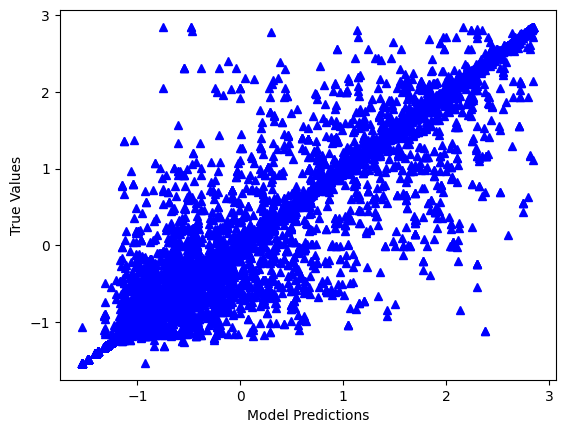

In [45]:
y_predict = DT_Model.predict(X_test)
plt.plot(y_predict,y_test,'^',color='b')
plt.xlabel('Model Predictions')
plt.ylabel('True Values')

6914/6914 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


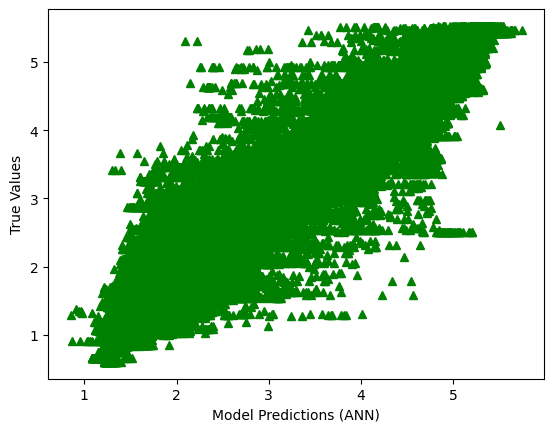

In [47]:
y_predict_ann = ANN_model.predict(X_test).reshape(-1,1)
y_predict_ann_orig = y_scaler.inverse_transform(y_predict_ann)

plt.plot(y_predict_ann_orig, y_test_orig, "^", color='g')
plt.xlabel('Model Predictions (ANN)')
plt.ylabel('True Values')
plt.show()

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
RMSE_ann = float(format(np.sqrt(mean_squared_error(y_test_orig, y_predict_ann_orig)),'.3f'))
MAE_ann = mean_absolute_error(y_test_orig, y_predict_ann_orig)
r2_ann = r2_score(y_test_orig, y_predict_ann_orig)

print('ANN RMSE =', RMSE_ann, '\nANN MAE =', MAE_ann, '\nANN R2 =', r2_ann)

ANN RMSE = 0.286 
ANN MAE = 0.20396788984731976 
ANN R2 = 0.935153798046345


In [50]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'ANN'],
    'Accuracy/R2': [0.6798, 0.9924, 0.8880, r2_ann]
})
print(comparison)

               Model  Accuracy/R2
0  Linear Regression     0.679800
1      Decision Tree     0.992400
2      Random Forest     0.888000
3                ANN     0.935154


In [51]:
ANN_model.save('/content/drive/MyDrive/Dataset for mining/ANN_model_v2.keras')
print(" ANN Model saved successfully!")

 ANN Model saved successfully!


In [52]:
sample_index = 5
sample_data = X_test[sample_index].reshape(1, -1)   # yahan reshape add kiya

pred_scaled = ANN_model.predict(sample_data)
pred_orig = y_scaler.inverse_transform(pred_scaled.reshape(-1,1))

actual_orig = y_scaler.inverse_transform(y_test[sample_index].reshape(-1,1))

print(f"Predicted % Silica (ANN): {pred_orig[0][0]:.3f}%")
print(f"Actual % Silica:          {actual_orig[0][0]:.3f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step
Predicted % Silica (ANN): 1.287%
Actual % Silica:          1.180%


In [53]:
for idx in [25, 75, 150, 300]:
    sample = X_test[idx].reshape(1, -1)
    pred = ANN_model.predict(sample)
    pred_orig = y_scaler.inverse_transform(pred.reshape(-1,1))
    actual_orig = y_scaler.inverse_transform(y_test[idx].reshape(-1,1))

    print(f"Sample {idx}: Predicted = {pred_orig[0][0]:.3f}%, Actual = {actual_orig[0][0]:.3f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Sample 25: Predicted = 1.744%, Actual = 1.030%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Sample 75: Predicted = 3.928%, Actual = 3.930%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Sample 150: Predicted = 4.536%, Actual = 4.650%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Sample 300: Predicted = 3.830%, Actual = 4.260%
